# Introduction

In [95]:
from IPython.display import Image, display

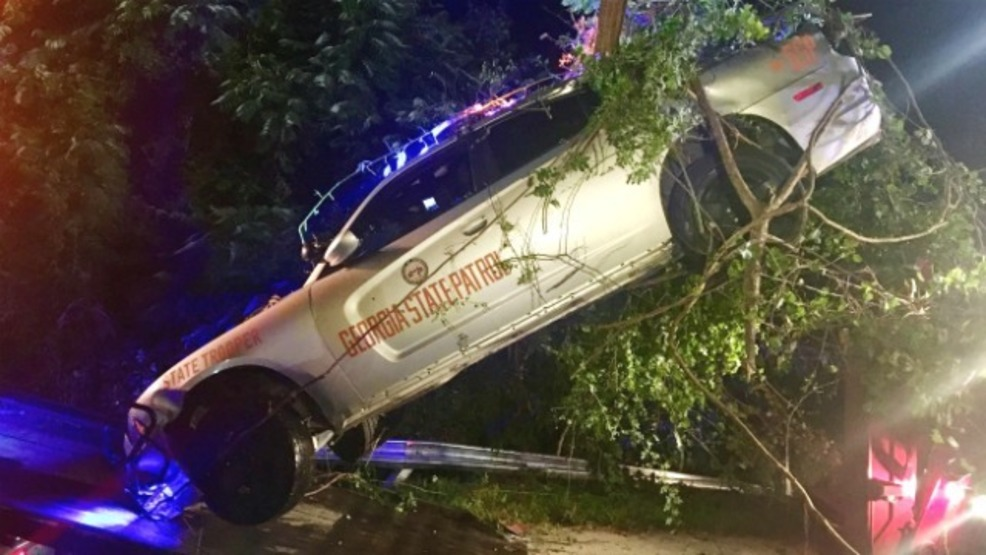

In [96]:
url ='geo_police_incident.jpg'
display(Image(url))

# Project Overview

This notebook presents a geospatial and criminological analysis of emergency incident data from Lithuania's **112 emergency response system**. The goal is to identify spatial, temporal, demographic, and social patterns in emergency service demand across major Lithuanian cities.

The analysis consists of the following stages:

1. **Data Loading and Preparation**

   * Load, clean, and preprocess the incident data.
   * Standardize variables and prepare geographic information for analysis.

2. **Geographic Enrichment**

   * Integrate external data on cities, roads, population, and natural features.
   * Provide spatial context for incident locations.

3. **Exploratory Data Analysis**

   * Examine incident distributions, temporal trends, and geographic hotspots.
   * Compare incident patterns across selected cities.

4. **Statistical and Spatial Analysis**

   * Investigate relationships between incidents, location, population, and environmental factors.
   * Evaluate the significance of observed patterns.

5. **Focused Incident Analyses**

   * **Medical Incidents:** city-level patterns, ambulance calls, and demographic influences.
   * **Police Incidents:** traffic offences, domestic violence, property crime, and public order violations.
   * **Natural Features:** relationship between serious incidents and proximity to rivers, lakes, and other natural features.
   * **Weapons and Explosives:** analysis of incidents involving weapons, ammunition, and explosion threats.

6. **Conclusions**

   * Summarize key findings and discuss implications for public safety, emergency response, and resource allocation.

The analysis combines emergency incident data with geographic and criminological context to provide a deeper understanding of urban safety patterns in Lithuania.


## Necessities

In [23]:
!pip install -q pyogrio

In [74]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import geopandas as gpd
from PIL import Image
from scipy.stats import spearmanr
import pyogrio
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Define dark blue color constants
DARK_BLUE_DISCRETE_SEQUENCE = [
    '#003f5c', '#2f4b7c', '#665191', '#a05195', '#d4b9da', '#f9d5e5', '#e8e8e8'
]

DARK_BLUE_CMAP = sns.light_palette("#003f5c", as_cmap=True)

DARK_BLUE_CONTINUOUS_SCALE = [
    [0, '#e8e8e8'],
    [0.2, '#d4b9da'],
    [0.4, '#a05195'],
    [0.6, '#665191'],
    [0.8, '#2f4b7c'],
    [1, '#003f5c']
]

DARK_BLUE_PALETTE = sns.color_palette(DARK_BLUE_DISCRETE_SEQUENCE)


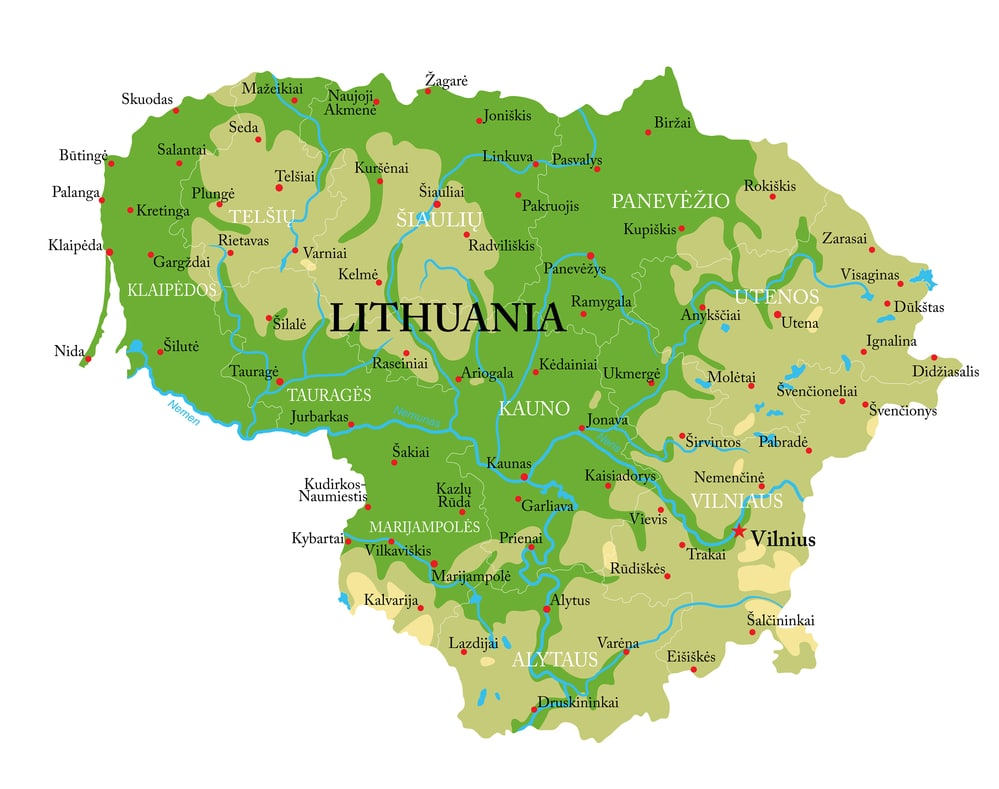

In [25]:
url = 'lt_map.jpg'
display(Image.open(url))

# 1. EDA

In [26]:
df = pd.read_csv('112.csv')
df.head()

,X,Y,ivykio_tipo_kodas,ivykio_id,metai,menuo,aukstesnis_ivykio_tipas,zemesnis_ivykio_tipas,object_id
0,455179,6202578,2.1,8a05b17d59f0,2022,3,BPC-GMP,GMP įvykis,1
1,496996,6088060,2.1,c9ffee4c15df,2022,3,BPC-GMP,GMP įvykis,2
2,396311,6243084,2.1,c349aa73f059,2022,3,BPC-GMP,GMP įvykis,3
3,509278,6113549,2.1,23b71b2f9a07,2022,3,BPC-GMP,GMP įvykis,4
4,323452,6174157,6.1.2,a15a6960d21f,2022,3,Policijos įvykiai,KET pažeidimas,5


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527053 entries, 0 to 1527052
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   X                        1527053 non-null  int64 
 1   Y                        1527053 non-null  int64 
 2   ivykio_tipo_kodas        1527050 non-null  object
 3   ivykio_id                1527053 non-null  object
 4   metai                    1527053 non-null  int64 
 5   menuo                    1527053 non-null  int64 
 6   aukstesnis_ivykio_tipas  1527050 non-null  object
 7   zemesnis_ivykio_tipas    1527050 non-null  object
 8   object_id                1527053 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 104.9+ MB


Provided data displays that there are overall 132602 data points with 9 different features including both numerical and categorical data.

## 1.1 Data Cleansing

In [28]:
df.columns

Index(['X', 'Y', 'ivykio_tipo_kodas', 'ivykio_id', 'metai', 'menuo',
       'aukstesnis_ivykio_tipas', 'zemesnis_ivykio_tipas', 'object_id'],
      dtype='object')

In [29]:
df.head()

,X,Y,ivykio_tipo_kodas,ivykio_id,metai,menuo,aukstesnis_ivykio_tipas,zemesnis_ivykio_tipas,object_id
0,455179,6202578,2.1,8a05b17d59f0,2022,3,BPC-GMP,GMP įvykis,1
1,496996,6088060,2.1,c9ffee4c15df,2022,3,BPC-GMP,GMP įvykis,2
2,396311,6243084,2.1,c349aa73f059,2022,3,BPC-GMP,GMP įvykis,3
3,509278,6113549,2.1,23b71b2f9a07,2022,3,BPC-GMP,GMP įvykis,4
4,323452,6174157,6.1.2,a15a6960d21f,2022,3,Policijos įvykiai,KET pažeidimas,5


In [30]:
# Translation from LT TO ENG
df.rename(columns={'X':'longitude','Y':'latitude', 'aukstesnis_ivykio_tipas':'higher_level_incident_type','zemesnis_ivykio_tipas':'lower_level_incident_type','metai':'year','menuo':'month','ivykio_tipo_kodas':'incident_type_code','ivykio_id': 'incident_id' }, inplace=True)
df.head()

,longitude,latitude,incident_type_code,incident_id,year,month,higher_level_incident_type,lower_level_incident_type,object_id
0,455179,6202578,2.1,8a05b17d59f0,2022,3,BPC-GMP,GMP įvykis,1
1,496996,6088060,2.1,c9ffee4c15df,2022,3,BPC-GMP,GMP įvykis,2
2,396311,6243084,2.1,c349aa73f059,2022,3,BPC-GMP,GMP įvykis,3
3,509278,6113549,2.1,23b71b2f9a07,2022,3,BPC-GMP,GMP įvykis,4
4,323452,6174157,6.1.2,a15a6960d21f,2022,3,Policijos įvykiai,KET pažeidimas,5


In [31]:
df.loc[:, 'higher_level_incident_type'] = df['higher_level_incident_type'].replace({'BPC-GMP':'Emergency Response Center → Ambulance Service','Policijos įvykiai':'Police incidents','Konsultacija':'Consultation','PGT įvykiai':'Fire and Rescue Department incidents','Aplinkosauga':'Environmental protection','BPC TRUKDANTIS':'Obstructing/disrupting the Emergency Response Center','SPEC tarnybos':'Special services','LAKD':'Lithuanian Road Administration','BPC-PGT':'Emergency Response Center → Fire and Rescue','Pagalba 112': '112 assistance','GMP įvykiai':'Ambulance services incidents','Testavimo pratybos': 'Testing exercises / drills', 'POLICIJOS pareigūnų korupcija *': 'Corruption of police officers'})

In [32]:
df.loc[:, 'lower_level_incident_type'] = df['lower_level_incident_type'].replace({
    'GMP įvykis': 'Ambulance incident',
    'KET pažeidimas': 'Traffic violation',
    'Pavojus eismo saugumui': 'Danger to traffic safety',
    'Ekonominės ir verslo tvarkos veikos': 'Economic and business order offenses',
    'Konsultacija': 'Consultation',
    'Turtinė veika anksčiau': 'Previous property crime',
    'eCall': 'eCall',
    'Eismo įvykis': 'Traffic accident',
    'Lavonas': 'Dead body',
    'Neklasifikuoti': 'Unclassified',
    'Rasti ar pamesti daiktai': 'Found or lost items',
    'Kompleksinis įvykis': 'Complex incident',
    'Sprogimas ar sprogimo grėsmė': 'Explosion or explosion threat',
    'Įvairūs viešosios tvarkos pažeidimai': 'Various public order violations',
    'Nusikaltimai asmeniui dabar': 'Crimes against person (current)',
    'Gaisras 0': 'Fire 0',
    'Nusikaltimai asmeniui anksčiau': 'Previous crimes against person',
    'Teisės pažeidimai aplinkosaugos srityje': 'Environmental law violations',
    'BPC TRUKDANTIS': 'Obstructing emergency center',
    'Auto 1': 'Vehicle incident 1',
    'Gelbėjimas': 'Rescue',
    'Smurtas artimoje aplinkoje': 'Domestic violence',
    'Turtinė veika dabar': 'Current property crime',
    'Pagalba specialiosioms tarnyboms': 'Assistance to special services',
    'Įvykiai su laukiniais gyvūnais': 'Wild animal incidents',
    'Pavojus gyvybei': 'Life-threatening danger',
    'Įtartini asmenys': 'Suspicious persons',
    'Gaisras 1': 'Fire 1',
    'Vanduo': 'Water',
    'SPEC tarnybos': 'Special services',
    'Narkotinės medžiagos': 'Narcotic substances',
    'Asmens paieška': 'Missing person search',
    'Žolė': 'Grass fire',
    'Nafta': 'Oil',
    'LAKD': 'Road administration',
    'Gaisras 1AK': 'Fire 1AK',
    'Įvykiai, susiję su policijos veikla': 'Police-related incidents',
    'Įvykiai dėl kurių gali kilti ar kilo pavojus gyventojams ar aplinkai':
        'Incidents dangerous to residents or environment',
    'PGT neklasifikuoti': 'Fire department unclassified',
    'Demerkurizavimas': 'Mercury cleanup',
    'Ginklai, šaudmenys, karo laikų sprogmenys':
        'Weapons, ammunition, wartime explosives',
    'Auto 2': 'Vehicle incident 2',
    'Chemija - Vanduo': 'Chemical - Water',
    'Gaisras 3': 'Fire 3',
    'Gaisras 2': 'Fire 2',
    'Neigiama informacija internete': 'Negative information online',
    'Chemija': 'Chemical incident',
    'Neapykantos kalba ir neapykantos kurstymas':
        'Hate speech and incitement',
    'Žolė (SA)': 'Grass fire (special response)',
    'BPC-GMP': 'Emergency center - ambulance',
    'Gaisras (SA)': 'Fire (special response)',
    'Gelbėjimo darbai (SA)': 'Rescue operations (special response)',
    'PGT pratybos': 'Fire department exercises',
    'Aukštis': 'Height rescue',
    'Demerkurizavimas (SA)': 'Mercury cleanup (special response)',
    'Pagalba 112': '112 assistance',
    'PGT neklasifikuoti (SA)': 'Fire department unclassified (special response)',
    'Pratybos (SA)': 'Exercises (special response)',
    'Aukštis AK': 'Height rescue AK',
    'Kiti psichikos ir elgesio sutrikimai':
        'Other mental and behavioral disorders',
    'Pervežimas': 'Transport',
    'Ūmus kraujotakos sutrikimas': 'Acute circulatory disorder',
    'Dusulys': 'Shortness of breath',
    'Kūno temperatūros pokyčiai': 'Body temperature changes',
    'Gausus vėmimas, viduriavimas': 'Severe vomiting or diarrhea',
    'Širdies veiklos sutrikimai': 'Heart disorders',
    'Miršta, nekvėpuoja, mėlynuoja': 'Dying, not breathing, turning blue',
    'Budėjimas renginyje, laidotuvėse':
        'Standby at event or funeral',
    'Įvairios sunkios traumos': 'Various severe injuries',
    'Šlapimo susilaikymas': 'Urinary retention',
    'Sąmonės sutrikimas': 'Consciousness disorder',
    'Pilvo skausmas': 'Abdominal pain',
    'Smurtas/prievartavimas': 'Violence/rape',
    'Skubus pervežimas': 'Urgent transport',
    'Neramumas / susijaudinimas': 'Restlessness/agitation',
    'Epideminė situacija': 'Epidemic situation',
    'Transporto priemonių avarija': 'Vehicle accident',
    'Insultas': 'Stroke',
    'Traukuliai': 'Seizures',
    'Dubliuotas kvietimas': 'Duplicate call',
    'Perduota kitoms tarnyboms': 'Transferred to other services',
    'Kraujavimas (netrauminis)': 'Non-traumatic bleeding',
    'Stiprus skausmas': 'Severe pain',
    'Skambutis ne GMP tikslais': 'Call not related to ambulance services',
    'Ūmi alerginė reakcija': 'Acute allergic reaction',
    'Galvos skausmas': 'Headache',
    'Ekstremalusis įvykis': 'Extreme incident',
    'Kvietimas pas vaiką iki 1 metų amžiaus':
        'Call for child under 1 year old',
    'Perimtas insultas': 'Transferred stroke case',
    'Krūtinės skausmas': 'Chest pain',
    'Nugaros skausmas': 'Back pain',
    'Gulintis_žmogus': 'Person lying down',
    'Ūmus apsinuodijimas': 'Acute poisoning',
    'Diabeto komplikacijos': 'Diabetes complications',
    'Bandymas nusižudyti (savižudybės pavojus)':
        'Suicide attempt (suicide risk)',
    'Nenormalus kraujospūdis': 'Abnormal blood pressure',
    'Gaisras pastate, nežinoma situacija':
        'Building fire, unknown situation',
    'Sunkūs nudegimai': 'Severe burns',
    'Atsisakė/Atsakytas': 'Refused/responded',
    'Įtariamas vidinis kraujavimas': 'Suspected internal bleeding',
    'Pagalba kitoms tarnyboms': 'Assistance to other services',
    'Sąmonės netekimas': 'Loss of consciousness',
    'GMP kvietimas_Panevėžys': 'Ambulance call - Panevėžys',
    'Lengvesnio ir vidutinio sunkumo traumos':
        'Minor and moderate injuries',
    'Lėtinių ligų paūmėjimas': 'Chronic disease exacerbation',
    'Mirties konstatavimas': 'Confirmation of death',
    'Komercinis pervežimas': 'Commercial transport',
    'Užspringimas': 'Choking',
    'Parezė/paralyžius': 'Paresis/paralysis',
    'Nėštumo komplikacijos': 'Pregnancy complications',
    'Akių sužalojimai': 'Eye injuries',
    'Skambinančiajam reikalaujant': 'At caller request',
    'Perimtas infarktas': 'Transferred heart attack case',
    'Gyvūnų įkandimai': 'Animal bites',
    'Viešosios tvarkos pažeidimai': 'Public order violations',
    'Chemija (SA)': 'Chemical incident (special response)',
    'Žaibo ir elektros sukelti pažeidimai':
        'Lightning and electricity injuries',
    'SPT': 'Special services',
    'Įvairios lokalizacijos svetimkūniai':
        'Foreign bodies in various locations',
    'Kritimai iš aukščio': 'Falls from height',
    'Rinkimų tvarkos pažeidimai': 'Election law violations',
    'Alerginė reakcija': 'Allergic reaction',
    'Gaisras, kurio metu nukentėjo žmonės':
        'Fire with injured people',
    'Gyvūnų įkandimai (nežymūs), įdrėskimai, apseilėjimai':
        'Minor animal bites, scratches, saliva exposure',
    'Perimta politrauma': 'Transferred polytrauma',
    'Testavimo pratybos': 'Testing exercises',
    'Komplikacijos po gimdymo': 'Postpartum complications',
    'Nušalimai': 'Frostbite',
    'Pasikorimas ir pasismaugimas': 'Hanging and strangulation',
    'Ūmus regėjimo sutrikimas, apakimas':
        'Acute vision disorder, blindness',
    'Gaisras 4': 'Fire 4',
    'Skendimas': 'Drowning',
    'POLICIJOS pareigūnų korupcija *': 'Police officer corruption',
    'Gelbėjimo darbai': 'Rescue operations',
    'Aplinkosauga': 'Environmental protection',
    'Saulės, šilumos smūgis': 'Heatstroke/sunstroke',
    'Valstybės tarnautojų korupcija':
        'Public servant corruption',
    'GMP konsultacija': 'Ambulance consultation',
    'Nežymūs nušalimai, nudegimai':
        'Minor frostbite and burns',
    'ATOMINĖ': 'Nuclear incident',
    'Turtinė veika': 'Property crime',
    'GMP įvykiai': 'Ambulance incidents',
    'Kaliningrado tranzitas': 'Kaliningrad transit',
    'Gaisrai': 'Fires',
    'Kiti įvykiai': 'Other incidents',
    'Griūtis': 'Collapse',
    'Pagalbos tarnybų pareigūnų prašymas':
        'Request from emergency service officers',
    'Eismo saugumas': 'Traffic safety',
    'Gaisras 5': 'Fire 5',
    'Nėštumas, gimdymas': 'Pregnancy and childbirth',
    'Radiacija': 'Radiation',
    '116000': '116000 hotline',
    'Ginklai, šaudmenys, sprogmenys':
        'Weapons, ammunition, explosives',
    'Nusikaltimai asmeniui': 'Crimes against person'
})

Since the dataset uses Lithuania's national coordinate system, the coordinates were transformed into the international WGS84 (EPSG:4326) standard to enable map-based visualisation.

In [33]:
geometry = [Point(xy) for xy in zip(df['longitude'],df['latitude'])]
df = gpd.GeoDataFrame(df,geometry=geometry,crs='EPSG:3346')
# Transform to WGS84 (EPSG:4326)
df = df.to_crs(epsg=4326)
df['longitude']= df.geometry.x
df['latitude'] = df.geometry.y

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df[df.isna().any(axis=1)]

,longitude,latitude,incident_type_code,incident_id,year,month,higher_level_incident_type,lower_level_incident_type,object_id,geometry
796703,21.160301,55.720911,NaN,bd7fd27e88e1,2023,4,NaN,NaN,796704,POINT (21.1603 55.72091)
1254657,22.330646,56.344855,NaN,a4317285e92d,2023,5,NaN,NaN,1254658,POINT (22.33065 56.34485)
1255859,23.864662,54.646945,NaN,ddb99be79bed,2023,5,NaN,NaN,1255860,POINT (23.86466 54.64695)


This row does not include any paramount details so dropping it will not have any impact on future analysis.

In [36]:
df.drop(132601)

,longitude,latitude,incident_type_code,incident_id,year,month,higher_level_incident_type,lower_level_incident_type,object_id,geometry
0,23.282309,55.955301,2.1,8a05b17d59f0,2022,3,Emergency Response Center → Ambulance Service,Ambulance incident,1,POINT (23.28231 55.9553)
1,23.953132,54.928555,2.1,c9ffee4c15df,2022,3,Emergency Response Center → Ambulance Service,Ambulance incident,2,POINT (23.95313 54.92855)
2,22.324267,56.309919,2.1,c349aa73f059,2022,3,Emergency Response Center → Ambulance Service,Ambulance incident,3,POINT (22.32427 56.30992)
3,24.145582,55.157485,2.1,23b71b2f9a07,2022,3,Emergency Response Center → Ambulance Service,Ambulance incident,4,POINT (24.14558 55.15748)
4,21.193270,55.669982,6.1.2,a15a6960d21f,2022,3,Police incidents,Traffic violation,5,POINT (21.19327 55.66998)
...,...,...,...,...,...,...,...,...,...,...
1527048,24.768147,56.203197,4.2.1,887453b76118,2022,12,Ambulance services incidents,Call for child under 1 year old,1527049,POINT (24.76815 56.2032)
1527049,26.246292,55.734289,6.6.1,22548943c359,2022,12,Police incidents,Previous property crime,1527050,POINT (26.24629 55.73429)
1527050,25.224020,54.733318,6.4.9,57a493a85be7,2022,12,Police incidents,Unclassified,1527051,POINT (25.22402 54.73332)
1527051,24.779191,55.256176,6.4.11,6d92a39f2158,2022,12,Police incidents,Found or lost items,1527052,POINT (24.77919 55.25618)


## 2 Core Features

In [37]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1527053 entries, 0 to 1527052
Data columns (total 10 columns):
 #   Column                      Non-Null Count    Dtype   
---  ------                      --------------    -----   
 0   longitude                   1527053 non-null  float64 
 1   latitude                    1527053 non-null  float64 
 2   incident_type_code          1527050 non-null  object  
 3   incident_id                 1527053 non-null  object  
 4   year                        1527053 non-null  int64   
 5   month                       1527053 non-null  int64   
 6   higher_level_incident_type  1527050 non-null  object  
 7   lower_level_incident_type   1527050 non-null  object  
 8   object_id                   1527053 non-null  int64   
 9   geometry                    1527053 non-null  geometry
dtypes: float64(2), geometry(1), int64(3), object(4)
memory usage: 116.5+ MB


> ### **longitude**
This feature is represents geographic coordinate of east-west approximate position of the accident.

> ### **latitude**
Property illustrated geographic coordinate representing the north-south position of the incident's approximate location.

##### Illustration of map with accident points (taken random sample n = 10000)

In [38]:
df_sample = df.sample(n=10000, random_state=42)
fig_sample = px.scatter_mapbox(
    df_sample,
    lat="latitude",
    lon="longitude",
    color="higher_level_incident_type",
    color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE,
    hover_data=['year', 'higher_level_incident_type', 'lower_level_incident_type'],
    zoom=6,
    height=900,
    width=900,
    title="Sample of Incident Locations by Higher-Level Incident Type"
)

fig_sample.update_layout(
    mapbox_style="open-street-map"
)

fig_sample.show()

> ### **higher_level_incident_type**
Attribute that explicates the general category of the emergency incident.

In [39]:
print(f'There are {df.higher_level_incident_type.nunique()} diverse categories of accidents.')

There are 15 diverse categories of accidents.


In [40]:
df[['higher_level_incident_type']].value_counts()

,count
higher_level_incident_type,
Police incidents,646162
Emergency Response Center → Ambulance Service,627520
Ambulance services incidents,160405
Fire and Rescue Department incidents,37822
Consultation,20453
Environmental protection,20340
Obstructing/disrupting the Emergency Response Center,6112
Special services,4100
Lithuanian Road Administration,2055


### Conclusions from Higher-Level Incident Type Counts

Based on the frequency of each `higher_level_incident_type`, here are some key conclusions:

1.  **Dominant Incident Types:** `Police incidents` and `Emergency Response Center → Ambulance Service` are the most prevalent categories, accounting for over 800,000 occurrences. These two types represent the  overwhelming majority of reported incidents, indicating the primary workload for emergency services.

2.  **Next Tier of Significance:** `Ambulance services incidents`, `Fire and Rescue Department incidents`, `Consultation`, and `Environmental protection` comprise the next level of incident frequency. While significant, their counts are considerably lower than the top two .

3.  **Rare Occurrences:** Categories like `112 assistance`, `Corruption of police officers`, and `116000` are extremely rare, appearing with very low single-digit counts. `Testing exercises / drills` also falls into this low-frequency group, suggesting these are either highly specialized, infrequent, or simulated events.

> ### **lower_level_incident_type**
Characteristic that exemplifies the specific type of emergency incident within a broader incident category.

In [41]:
print(f'There are {df.lower_level_incident_type.nunique()} subcategories of incidents in this dataset.')

There are 151 subcategories of incidents in this dataset.


In [42]:
df[['lower_level_incident_type']].value_counts()

,count
lower_level_incident_type,
Ambulance incident,572258
Traffic violation,146854
Various public order violations,125352
Previous property crime,67671
Domestic violence,64154
...,...
Fires,2
Radiation,2
116000 hotline,1


### Conclusions about Lower-Level Incident Types

Based on the frequency of `lower_level_incident_type`, here are some key conclusions:

1.  **Dominant Subcategory**: `Ambulance incident` is by far the most frequent specific type of incident, accounting for a massive number of calls (over 572,000).
2.  **Key Police-Related Subcategories**: Following ambulance calls, several police-related subcategories are prominent, including `Traffic violation`, `Various public order violations`, `Previous property crime`, and `Domestic violence`. These indicate areas requiring significant police resources.
3.  **Broad Spectrum of Incidents**: The dataset contains a very wide range of specific incident types, reflecting the diverse nature of emergencies that require response.
4.  **Extremely Rare Subcategories**: Similar to the higher-level incidents, many lower-level incident types are extremely rare, appearing with only 1, 2, 3, or 4 occurrences. These include very specific or unusual events like `Fires`, `116000 hotline`, `Crimes against person`, `Other incidents`, and `Pregnancy and childbirth`. This highlights highly specialized or infrequent emergency situations.

> ### **incident_type_code**
Given trait is a unique hierchical classification code used to identify the specific type of emergency incident with the BPC classification system.

In [43]:
print(f'There are {df.incident_type_code.nunique()} distinct emergency codes in the dataset.')

There are 152 distinct emergency codes in the dataset.


In [44]:
the_most_popular_emergency_codes = df[['higher_level_incident_type','lower_level_incident_type','incident_type_code']].value_counts()[:10]

In [45]:
the_most_popular_emergency_codes

higher_level_incident_type                     lower_level_incident_type        incident_type_code
Emergency Response Center → Ambulance Service  Ambulance incident               2.1                   572258
Police incidents                               Traffic violation                6.1.2                 146854
                                               Various public order violations  6.7.1                 125352
                                               Previous property crime          6.6.1                  67671
                                               Domestic violence                6.5.4                  64154
Emergency Response Center → Ambulance Service  Complex incident                 2.2                    55226
Police incidents                               Unclassified                     6.4.9                  46156
                                               Danger to traffic safety         6.1.3                  34023
                                               Crimes against person (current)  6.5.2                  26124
                                               Current property crime           6.6.2                  23994
Name: count, dtype: int64

In [46]:
fig = px.bar(the_most_popular_emergency_codes.reset_index(),x='higher_level_incident_type',y='count',color = 'lower_level_incident_type',title='Most popular emergency calls frequency', color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE)
fig.show()

In [47]:
the_least_popular_emergency_codes = df[['higher_level_incident_type','lower_level_incident_type','incident_type_code']].value_counts()[-10:]
the_least_popular_emergency_codes

higher_level_incident_type                   lower_level_incident_type     incident_type_code
Police incidents                             Traffic safety                6.1                   4
Emergency Response Center → Fire and Rescue  Exercises (special response)  3.7                   3
Environmental protection                     Environmental protection      1                     3
Ambulance services incidents                 Ambulance incidents           4                     2
Fire and Rescue Department incidents         Fire 5                        5.3.7                 2
                                             Fires                         5.3                   2
                                             Radiation                     5.2.5                 2
116000                                       116000 hotline                12                    1
Ambulance services incidents                 Pregnancy and childbirth      4.5                   1
Police incidents                             Other incidents               6.4                   1
Name: count, dtype: int64

The most popular emergency codes are:

In [48]:
px.bar(the_least_popular_emergency_codes.reset_index(),x='higher_level_incident_type',y='count',color='lower_level_incident_type',title='Least popular emergency calls frequency', color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE)

### Most Popular Emergency Incidents

1.  **Dominance of Ambulance Service Calls:** The most frequent emergency incidents are significantly related to `Emergency Response Center → Ambulance Service`, with `Ambulance incident` (code 2.1) being the most common by a large margin (over 250,000 occurrences).
2.  **Key Police Incident Types:** Among `Police incidents`, `Traffic violation` (code 6.1.2), `Various public order violations` (code 6.7.1), and `Previous property crime` (code 6.6.1) are the most frequent.
3.  **High-Frequency Categories:** The top 10 most popular emergency codes are dominated by core ambulance and police response categories, indicating the primary workload areas for emergency services.

### Least Popular Emergency Incidents

1.  **Extremely Rare Events:** The least popular emergency codes represent very rare occurrences, often with single-digit counts. These include highly specific or unusual incidents like `Pregnancy and childbirth`, `Other accidents`, and various specialized medical conditions.
2.  **Specialized/Anomalous Categories:** These low-frequency incidents often point to highly specialized responses or events that are thankfully uncommon.

### Reasoning Behind Incident Category Frequencies

The varying frequencies of incident categories are due to a combination of factors related to the nature of the incidents themselves, public behavior, and the structure of emergency services. Here's a breakdown of the reasoning:

### Why Some Categories "Win" (Are Highly Frequent):

1.  **Commonplace Occurrences**: Many high-frequency incidents are simply part of daily life. For example, `Ambulance incident` often covers a wide range of medical issues, from minor ailments to serious emergencies, which are statistically more likely to occur than, say, a nuclear incident. `Traffic violations` are also a frequent occurrence in any populated area with vehicles.
2.  **Broad Definitions**: Some categories, particularly `Ambulance incident` and `Police incidents`, act as umbrella terms for a multitude of specific events. This broadness naturally leads to higher counts as many different scenarios can fall under these general classifications.
3.  **Immediate Public Need**: Incidents like medical emergencies (`Ambulance Service`) and immediate threats to public order/safety (`Police incidents`) require urgent attention, making them the most common reasons for people to contact emergency services.
4.  **Accessibility and Awareness**: The public is generally well aware of when to call for an ambulance or police, and these services are the primary points of contact for a vast array of urgent situations.

### Why Some Categories "Do Not Win" (Are Infrequent):

1.  **Rarity of the Event**: Some incidents are inherently rare. Catastrophic events like `Radiation`, major `Fires` (especially higher classifications like `Fire 5`), or specific types of `Corruption` are thankfully not common occurrences in society.
2.  **Specialized Nature**: Certain categories might represent highly specialized or niche situations that occur infrequently. For instance, `116000 hotline` refers to a specific missing children hotline, which, while crucial, receives fewer calls than general emergency services.
3.  **Severity vs. Frequency**: While incidents like `Weapons, ammunition, explosives` or `Crimes against person` are extremely serious, their occurrence is (fortunately) much lower than more common issues like traffic violations or minor medical calls.
4.  **Alternative Reporting Channels**: Some specific incidents might have alternative, non-112 reporting mechanisms. For example, while environmental protection is important, many non-urgent environmental concerns might be reported directly to a specific environmental agency rather than the general emergency number.
5.  **Simulated/Training Events**: Categories like `Testing exercises / drills` are by definition infrequent, as they are controlled simulations rather than real-world emergencies.

In summary, the distribution reflects the day-to-day realities and risks faced by the population, with common, broad-scope incidents dominating the call volume, while rare, specialized, or catastrophic events occur with much lower frequency.

> ### **geometry**
Variable that elucidates the geospatial point object representing the incident's approximate location after coordinate system transformation.

> ### **year, month**
These descriptions are the calendar year, month during which the emergency incident has occured.

In [49]:
years = sorted(df.year.unique())
years_clean = [int(year) for year in years if not pd.isna(year)]
print(f'The unique years mentioned in the dataset: {years_clean}')

The unique years mentioned in the dataset: [2021, 2022, 2023]


In [50]:
df['year_month'] = pd.to_datetime(df['year'].astype(int).astype(str) + '-' + df['month'].astype(int).astype(str))
monthly_yearly_counts = df['year_month'].value_counts().reset_index()
monthly_yearly_counts.columns = ['year_month','count']
monthly_yearly_counts = monthly_yearly_counts.sort_values(by='year_month')
fig = px.line(monthly_yearly_counts,x='year_month',y='count')
fig.update_layout(title='Incident Count Fluctuations over time')
fig.update_traces(line_color=DARK_BLUE_DISCRETE_SEQUENCE[0])
fig

### Conclusions about Year and Month Data

Based on the analysis of the `year` and `month` data, several key observations can be made:

1. **Data Coverage:**
   The dataset spans from September 2021 to June 2023.

2. **Yearly Trends:**

   * **2022** recorded the highest number of incidents.
   * **2023** shows a lower total count compared to 2022; however, the data for 2023 is incomplete, covering only up to June.

3. **Monthly Patterns (Overall):**

   * When considering all years combined, some months tend to have higher incident counts (such as March, April, and May), while others show lower counts (such as February and September).
   * This suggests possible seasonal variation in incident occurrence.

4. **Combined Year–Month Trends:**

   * The `year_month` analysis shows a rise in incidents towards the end of 2021, followed by consistently high but fluctuating activity throughout most of 2022.
   * A substantial drop is observed in October 2022, where incident counts decrease sharply compared to surrounding months. This anomaly is unlikely to represent real-world conditions and most likely indicates missing or incomplete data, a data collection issue, or preprocessing/filtering errors.
   * The beginning of 2023 continues to show relatively high activity levels, with a slight decline observed by June 2023.


### Possible Reasons for Fluctuations Over Time

Fluctuations in incident counts over time may be caused by several factors, including:

1. **Seasonality:** Weather changes, daylight hours, and seasonal activities can affect incident rates.
2. **Holidays and Events:** Public holidays, festivals, and large gatherings may increase or decrease incidents.
3. **Socio-economic Factors:** Economic conditions and social trends can influence incident patterns over time.
4. **Reporting or System Changes:** Changes in reporting behavior or data collection methods may impact recorded counts.
5. **Specific Major Events:** Accidents, disasters, or protests can create temporary spikes.
6. **Incomplete Data:** Recent years may appear lower if data collection is not yet complete.


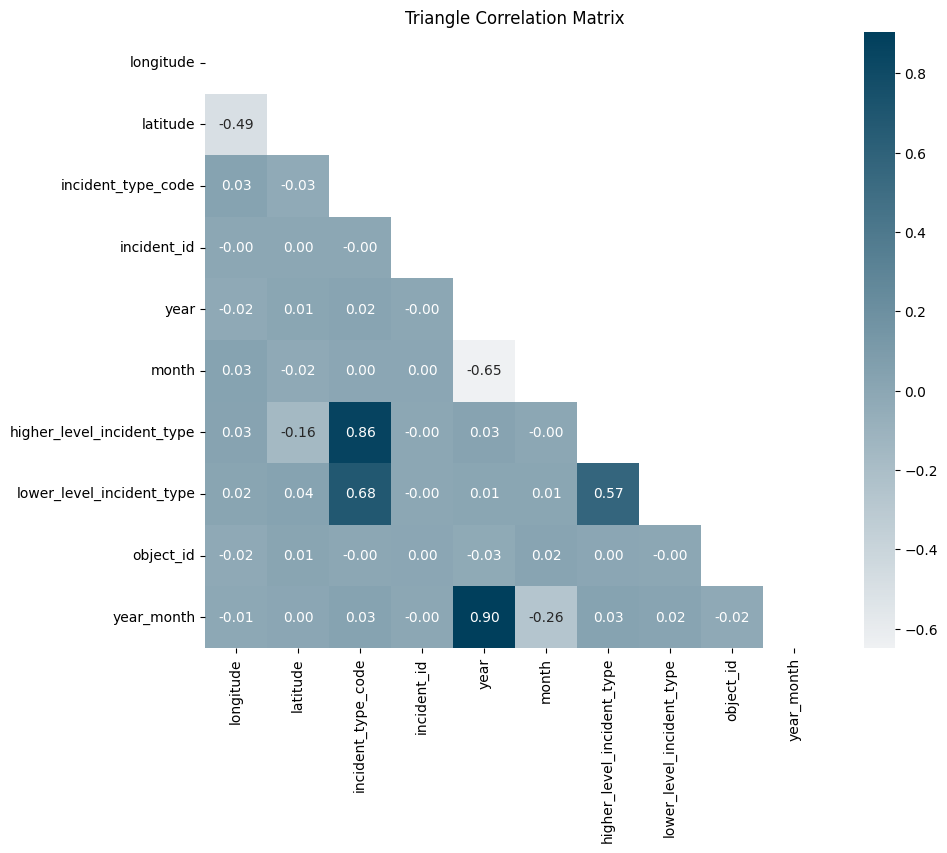

In [51]:
df_corr = df.copy()
df_corr = df_corr.drop(columns=['geometry'], errors='ignore')

for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

corr_matrix = df_corr.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=DARK_BLUE_CMAP,
    fmt='.2f',
    mask=mask
)

plt.title('Triangle Correlation Matrix')
plt.show()

By looking at the correlation matrix above, it's transparent that some connections between variables are natural since they are inherently linked or represent different facets of the same underlying information. For example, `year` and `month` are components of a temporal structure (`year_month`), so a correlation between them or between `year_month` and either `year` or `month` is expected. Similarly, `higher_level_incident_type` and `lower_level_incident_type` are hierarchical classifications, meaning they will inherently be related.

Although, there are also connections that are worth exploring such as:
1. **month VS latitude/longitude**
2. **year VS latitude/longitude**
3. **month VS lower_level_incident_type**
4. **year VS higher_level_incident_type/lower_level_incident_type**
5. **geospatial concentration of specific lower_level_incident_type**



# 3. Statistical Tests

### 3.1.  year_month VS higher_level_incident_type/lower_level_incident_type
#### Chi-square Test

**Null Hypothesis**: there is no relationship between the month and the occured type of accident.

**Alternative Hypothesis**: there is a connection between the month and the sort of incident happened.

In [52]:
contingency_table_1 = pd.crosstab(df.year_month,df.higher_level_incident_type)
stat_1,p_1,dof_1,expected_1 = chi2_contingency(contingency_table_1)

print(f'Chi-square statistic(month_year vs higher_level_incident_type): {stat_1}')
print(f'Degrees of freedom: {dof_1}')
print(f'p-value:{p_1:.6f}')


Chi-square statistic(month_year vs higher_level_incident_type): 12564.127824323874
Degrees of freedom: 280
p-value:0.000000


In [53]:
contingency_table_2 = pd.crosstab(df.year_month,df.lower_level_incident_type)
stat_2,p_2,dof_2,expected_2 = chi2_contingency(contingency_table_2)

print(f'Chi-square statistic(month_year vs higher_level_incident_type): {stat_2}')
print(f'Degrees of freedom: {dof_2}')
print(f'p-value:{p_2:.6f}')

Chi-square statistic(month_year vs higher_level_incident_type): 43884.90906086583
Degrees of freedom: 3000
p-value:0.000000


**Checking effect size**:
Cramer's test allows to test on HOW POWERFUL the relationship is.

In [54]:
n_1 = contingency_table_1.sum().sum()
rows_1,cols_1 = contingency_table_1.shape
cramers_v_1 = np.sqrt(stat_1 /(n_1 *(min(rows_1,cols_1)-1)))
print(f'{cramers_v_1:.4f}')

0.0242


In [55]:
n_2 = contingency_table_2.sum().sum()
rows_2,cols_2 = contingency_table_2.shape
cramers_v_2 = np.sqrt(stat_2 /(n_2 *(min(rows_2,cols_2)-1)))
print(f'{cramers_v_2:.4f}')

0.0379


| Cramér’s V | Strength  |
| ---------- | --------- |
| 0.00–0.10  | very weak |
| 0.10–0.30  | weak      |
| 0.30–0.50  | moderate  |
| >0.50      | strong    |


Consequently, even though the p-value is less than 0.05 and the null hypothesis can be rejected, Cramér’s V statistics of 0.0242 and 0.0379 indicate a very weak association between the variables.

**While the associations between accidents and month, and between accidents and year, are statistically significant, their effect sizes are very small, indicating limited practical significance.**

### 3.2 year_month VS longitude/latitude
#### Spearman Test

**Null Hypothesis 1**: There is no correlation between the year_month and the longitude

**Null Hypothesis 2**: There is no correlation between the year_month and the latitude

**Alternative Hypothesis 1**: There is connection between the year_month and longitude variables

**Alternative Hypothesis 2**: There is no connection between the year_month and longitude attributes

In [56]:
df['year_month_numeric'] = df['year_month'].astype(int)

corr, p = spearmanr(
    df["year_month_numeric"],
    df["longitude"]
)

corr_2, p_2 = spearmanr(
    df["year_month_numeric"],
    df["latitude"]
)


print("Correlation (year_month vs longitude):", corr)
print("p-value:", p)
print("Correlation (year_month vs latitude):", corr_2)
print("p-value:", p_2)

Correlation (year_month vs longitude): -0.009769574862477044
p-value: 1.4681003058527876e-33
Correlation (year_month vs latitude): 0.004412462256012449
p-value: 4.9616986949222015e-08


Due to the reason that both p-values are less than the threshhold 0.5 it's possible to reject Null Hypothesis which means that relationship between year_month and longitude/latitude are statistically significant

**However, correlation coefficients themselves are very close to zero (0.0044 and -0.0097), indicating that while a relationship statistically exists, it is extremely weak and has little practical importance in explaining the variation in location based on time.In practical terms, these correlations suggest that knowing the time of the incident (year and month) tells you almost nothing about its geographical coordinates, and vice-versa, despite the statistical significance.**

# 4. Performing Spatial Joins

### Explanation of Spatial Joins (sjoin_nearest)

Throughout the notebook, several spatial join operations will be undertaken  using `geopandas.sjoin_nearest`. This function is powerful for enriching your incident data (`df`) with information from various geographical layers (cities, roads, buildings, natural features) based on proximity.

**What `sjoin_nearest` does:**
For each incident point in your main `df`, `sjoin_nearest` finds the geometrically closest feature (e.g., the nearest city, the nearest road segment, the nearest building, or the nearest natural feature) from another geographical dataset.

In [57]:
layers = pyogrio.list_layers("lithuania.gpkg")
print(layers)

[['gis_osm_traffic_free' 'Point']
 ['gis_osm_places_free' 'Point']
 ['gis_osm_pois_free' 'Point']
 ['gis_osm_transport_free' 'Point']
 ['gis_osm_natural_free' 'Point']
 ['gis_osm_pofw_free' 'Point']
 ['gis_osm_roads_free' 'LineString']
 ['gis_osm_railways_free' 'LineString']
 ['gis_osm_waterways_free' 'LineString']
 ['gis_osm_landuse_a_free' 'MultiPolygon']
 ['gis_osm_water_a_free' 'MultiPolygon']
 ['gis_osm_pois_a_free' 'MultiPolygon']
 ['gis_osm_pofw_a_free' 'MultiPolygon']
 ['gis_osm_buildings_a_free' 'MultiPolygon']
 ['gis_osm_traffic_a_free' 'MultiPolygon']
 ['gis_osm_transport_a_free' 'MultiPolygon']
 ['gis_osm_adminareas_a_free' 'MultiPolygon']
 ['gis_osm_places_a_free' 'MultiPolygon']
 ['gis_osm_protected_areas_a_free' 'MultiPolygon']
 ['gis_osm_natural_a_free' 'MultiPolygon']]


In [58]:
places = gpd.read_file(
    "lithuania.gpkg",
    layer="gis_osm_places_free"
)

print(f'Places columns: {places.columns.tolist()}')
roads = gpd.read_file(
    "lithuania.gpkg",
    layer="gis_osm_roads_free"
)
print(f'Roads columns: {roads.columns.tolist()}')

admin = gpd.read_file(
    "lithuania.gpkg",
    layer="gis_osm_adminareas_a_free"
)
print(f'Admin columns: {admin.columns.tolist()}')

buildings = gpd.read_file(
    "lithuania.gpkg",
    layer="gis_osm_buildings_a_free"
)

print(f'Buildings columns: {buildings.columns.tolist()}')

natural = gpd.read_file(
    "lithuania.gpkg",
    layer="gis_osm_natural_free"
)
print(f'Natural columns: {natural.columns.tolist()}')

Places columns: ['osm_id', 'code', 'fclass', 'population', 'name', 'geometry']
Roads columns: ['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'geometry']
Admin columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
Buildings columns: ['osm_id', 'code', 'fclass', 'name', 'type', 'geometry']
Natural columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']


In [59]:
miestai = places[
    (places["fclass"].isin(["city", "town", "national_capital"])) &
    (places["population"] > 10000)
]

In [60]:
df_proj = df.to_crs(epsg=3346)
miestai_proj = miestai.to_crs(epsg=3346)

city_join = gpd.sjoin_nearest(
    df_proj,
    miestai_proj[["name", "population", "geometry"]].reset_index(drop=True),
    how="left",
    max_distance=20000,
    distance_col="distance_to_city_m"
)

df["city_name"] = city_join["name"]
df["city_population"] = city_join["population"]
df["distance_to_city_m"] = city_join["distance_to_city_m"]

In [61]:
road_join = gpd.sjoin_nearest(
    df,
    roads[['name', 'fclass', 'geometry','maxspeed']],
    how='left'
)

road_join = road_join.rename(columns={
    'name': 'street_name',
    'fclass': 'road_type'
})

df = road_join

/tmp/ipykernel_140724/3312536420.py:1: UserWarning:

CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: OGC:CRS84


/usr/local/lib/python3.12/dist-packages/geopandas/array.py:411: UserWarning:

Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




Some incidents could not be assigned a street name because the nearest road segment in the OpenStreetMap dataset does not contain a recorded street name. This is common for pedestrian paths, service roads, cycleways, tracks, and other minor transportation features. In such cases, the road classification (e.g., footway, service, cycleway, residential) was retained and used as a proxy for location context.

In [62]:
df = df.drop(columns=["index_right"], errors="ignore")

In [63]:
buildings_join = gpd.sjoin_nearest(
    df,
    buildings [["osm_id", "fclass", "type", "name", "geometry"]
    ],
    how='left',
    distance_col=
    "distance_to_building_m"
)
road_join = road_join.rename(columns={
    "osm_id_right": "nearest_building_osm_id",
    "fclass_right": "nearest_building_class",
    "type_right": "nearest_building_type",
    "name_right": "nearest_building_name"
})

df = buildings_join

/tmp/ipykernel_140724/2548986435.py:1: UserWarning:

CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: OGC:CRS84


/usr/local/lib/python3.12/dist-packages/geopandas/array.py:411: UserWarning:

Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




In [64]:
df = df.drop(columns=["index_right"], errors="ignore")

In [65]:
natural_join = gpd.sjoin_nearest(
    df,
    natural[
        ["fclass", "name", "geometry"]
    ],
    how="left",
    distance_col="distance_to_natural_feature_m"
)
natural_join = natural_join.rename(columns={
    'fclass': 'natural feature',
    'name': 'natural element'
})
df = natural_join

/tmp/ipykernel_140724/3530308984.py:1: UserWarning:

CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: OGC:CRS84


/usr/local/lib/python3.12/dist-packages/geopandas/array.py:411: UserWarning:

Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




In [66]:
df = df.drop(
    columns=[
        "osm_id_left",
        "fclass_left",
        "type_left",
        "name_left",
        'nearest_building_class',
        'index_right',
        'nearest_building_osm_id',
        'year_month_numeric',
        "nearest_natural_feature",
        "nearest_natural_name",
        "distance_to_natural_feature_m",
        "index_right"
    ],
    errors="ignore"
)

In [67]:
useful_nature = natural[
    natural["fclass"].isin([
        "wood",
        "water",
        "wetland",
        "beach",
        "scrub"
    ])
].copy()

df_m = df.to_crs(3346)
natural_m = useful_nature.to_crs(3346)

natural_join = gpd.sjoin_nearest(
    df_m,
    natural_m[
        ["fclass", "name", "geometry"]
    ].reset_index(drop=True),
    how="left",
    distance_col="distance_to_natural_feature_m"
)

df["nearest_natural_feature"] = (
    natural_join["fclass"].values
)

df["nearest_natural_name"] = (
    natural_join["name"].values
)

df["distance_to_natural_feature_m"] = (
    natural_join["distance_to_natural_feature_m"].values
)

print(
    df[
        [
            "nearest_natural_feature",
            "nearest_natural_name",
            "distance_to_natural_feature_m"
        ]
    ].head()
)

  nearest_natural_feature          nearest_natural_name  \
0                   beach                                 
1                   beach                                 
2                   beach                                 
3                   beach                                 
4                   beach  Pervalkos nudistų paplūdimys   

   distance_to_natural_feature_m  
0                   40548.753816  
1                   32018.683185  
2                    1851.687999  
3                   49978.307859  
4                   29218.786884  


In [68]:
print('Distribution of higher_level_incident_type in df_corr (numerical codes):')
display(df_corr['higher_level_incident_type'].value_counts())

Distribution of higher_level_incident_type in df_corr (numerical codes):


,count
higher_level_incident_type,
11,646162
5,627520
2,160405
8,37822
3,20453
7,20340
10,6112
12,4100
9,2055


/tmp/ipykernel_140724/214080214.py:7: UserWarning:


The palette list has fewer values (7) than needed (11) and will cycle, which may produce an uninterpretable plot.



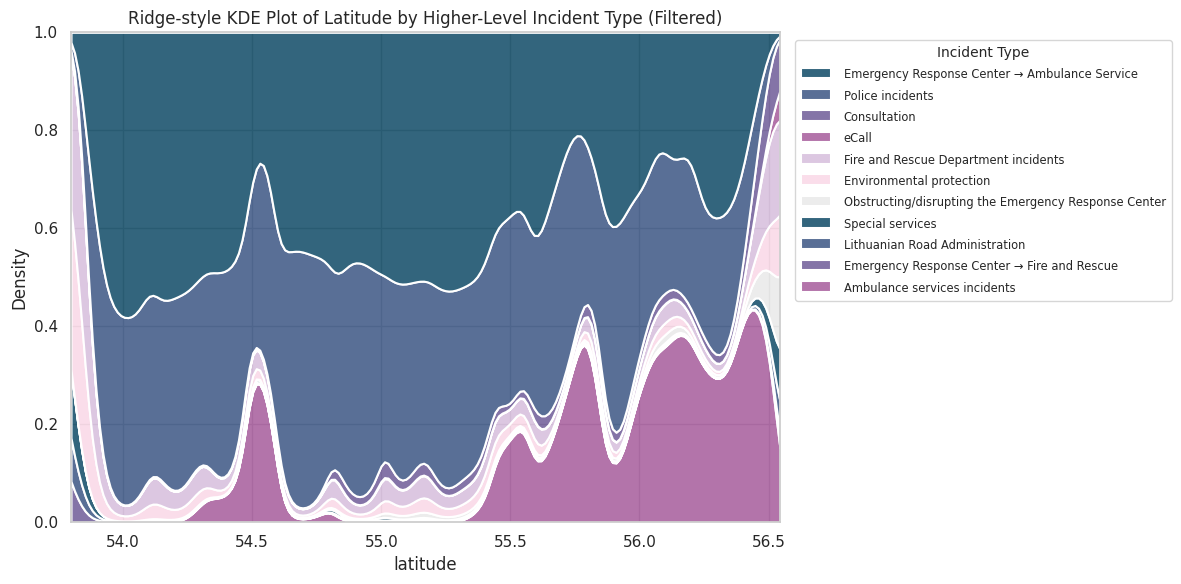

In [69]:
sns.set_theme(style="whitegrid")
value_counts = df['higher_level_incident_type'].value_counts()
meaningful_incident_types = value_counts[value_counts > 50].index
df_filtered = df[df['higher_level_incident_type'].isin(meaningful_incident_types)]

plt.figure(figsize=(12, 6))
ax = sns.kdeplot(
    data=df_filtered,
    x="latitude",
    hue="higher_level_incident_type",
    multiple="fill",
    alpha=0.8,
    linewidth=1.5,
    palette=DARK_BLUE_PALETTE
)

plt.title("Ridge-style KDE Plot of Latitude by Higher-Level Incident Type (Filtered)")

legend = ax.get_legend()
if legend:

    for text in legend.get_texts():
        text.set_fontsize('x-small')
    legend.set_title('Incident Type', prop={'size': 'small'})

    legend.set_bbox_to_anchor((1.01, 1))
    legend.set_loc('upper left')

plt.tight_layout()
plt.show()

### Summary of `higher_level_incident_type` Distribution

The `higher_level_incident_type` column in `df_corr` has been numerically encoded. To interpret these codes, we refer back to the original `df` DataFrame.

Based on the value counts (which reflect the frequency of each incident type), the distribution is as follows:

*   **Most Frequent Incident Types:**
    1.  `Police incidents` (code: 11) is the most frequent, count is 160405.
    2.  `Emergency Response Center → Ambulance Service` (code: 2) is the second most frequent, reaching the number 627520.
    3.  `Ambulance services incidents` (code: 3), accounting up to 20453.

*   **Less Frequent Incident Types:**
    *   Incident types like `Environmental protection` (code: 0), `Fire and Rescue Department incidents` (code: 7), and `Consultation` (code: 1) occur with moderate frequency.

*   **Rare Incident Types:**
    *   The least frequent categories include `Corruption of police officers` (code: 6), `112 assistance` (code: 4), and `116000` (code: 5), with very low counts, indicating their rarity in the dataset.

# 5. Incidents By Category Analysis
There overall are 4 main accidents types. In this examination medical and police accidents will be covered.




In [70]:
df.city_name.unique()

array(['Šiauliai', 'Kaunas', 'Mažeikiai', 'Jonava', 'Klaipėda', 'Palanga',
       'Radviliškis', 'Kuršėnai', nan, 'Garliava', 'Tauragė', 'Gargždai',
       'Telšiai', 'Elektrėnai', 'Kėdainiai', 'Jurbarkas', 'Šilutė',
       'Raseiniai', 'Plungė', 'Kretinga', 'Vilkaviškis', 'Utena',
       'Alytus', 'Vilnius', 'Visaginas', 'Druskininkai', 'Marijampolė',
       'Anykščiai', 'Panevėžys', 'Lentvaris', 'Ukmergė', 'Grigiškės',
       'Biržai', 'Rokiškis'], dtype=object)

In [71]:
incident_count_per_city = df.city_name.value_counts().reset_index()
incident_count_per_city.columns = ['city_name', 'incident_count']

##### Incident Counts by City

In [72]:
city_population_df = df[['city_name', 'city_population']].drop_duplicates().dropna()
city_population_df = city_population_df.sort_values(by='city_population', ascending=False)

In [75]:

incident_count_sorted = incident_count_per_city.sort_values(by='incident_count', ascending=True)
city_population_sorted = city_population_df.sort_values(by='city_population', ascending=True)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Incident Counts by City (Diverging Bar)', 'City Population (Horizontal Bar)'))

fig.add_trace(
    go.Bar(
        x=incident_count_sorted['incident_count'],
        y=incident_count_sorted['city_name'],
        orientation='h',
        marker=dict(
            color=incident_count_sorted['incident_count'],
            colorscale=DARK_BLUE_CONTINUOUS_SCALE
        ),
        name='Incident Count'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=city_population_sorted['city_population'],
        y=city_population_sorted['city_name'],
        orientation='h',
        marker=dict(
            color=city_population_sorted['city_population'],
            colorscale=DARK_BLUE_CONTINUOUS_SCALE,
            line=dict(color='DarkSlateGrey', width=1)
        ),
        name='Population'
    ),
    row=1, col=2
)

fig.update_layout(
    title_text='Incident Counts vs. City Population',
    height=800,
    showlegend=False,
    bargap=0.1
)

fig.update_xaxes(title_text='Incident Count', row=1, col=1)
fig.update_yaxes(title_text='City Name', row=1, col=1)
fig.update_xaxes(title_text='Population', row=1, col=2)
fig.update_yaxes(title_text='City Name', row=1, col=2, matches='y')

fig.show()

* **Population Effect:** Larger cities generally report more incidents due to higher population and activity levels.
* **Per-Capita Differences:** Some smaller cities show relatively high incident rates despite lower populations.
* **Outliers:** Cities that deviate from the population–incident trend may reflect unique local factors.
* **Resource Allocation:** Combining incident and population data helps identify areas with the greatest emergency service demand.


## In this analysis regions such Vilnius, Kaunas, Panevėžys, Klaipėda and Alytus will be assesed

In [76]:
selected_cities = ['Vilnius', 'Panevėžys', 'Kaunas', 'Klaipėda', 'Alytus']
cities_to_plot = miestai[miestai['name'].isin(selected_cities)].to_crs(epsg=4326)
cities_to_plot['longitude'] = cities_to_plot.geometry.x
cities_to_plot['latitude'] = cities_to_plot.geometry.y

fig_cities = px.scatter_mapbox(
    cities_to_plot,
    lat="latitude",
    lon="longitude",
    hover_name="name",
    hover_data=["population"],
    color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE,
    zoom=6,
    height=600,
    width=800,
    title="Selected Cities in Lithuania"
)

fig_cities.update_layout(mapbox_style="open-street-map")
fig_cities.show()

### 5.1 Medical Acccidents Report

This section examines the distribution of medical incidents across Vilnius, Kaunas, Klaipėda, Panevėžys, and Alytus. The analysis focuses on ambulance and complex incidents, compares incident volumes with population size, and explores potential demographic influences.

Previous research suggests that emergency medical service demand is strongly associated with population size, age structure, and the prevalence of chronic diseases. In Lithuania, regions with older populations often experience higher demand for ambulance services due to cardiovascular diseases, falls, and other age-related health conditions (Lithuanian Institute of Hygiene; Statistics Lithuania). This context is particularly relevant when interpreting the relatively high number of medical incidents observed in Panevėžys despite its smaller population.

By combining incident data with demographic and geographic context, this analysis aims to identify patterns in emergency healthcare demand and provide insights relevant to public health planning and emergency resource allocation.

In [77]:
medical_incident_types = [
    'Emergency Response Center → Ambulance Service',
    'Ambulance services incidents'
]

medical_accidents_in_cities = df[
    df['higher_level_incident_type'].isin(medical_incident_types) &
    df['city_name'].isin(selected_cities)
]
selected_cities = ['Vilnius', 'Panevėžys', 'Kaunas', 'Klaipėda', 'Alytus']

### Medical Accidents in Selected Cities

In [78]:

medical_accident_counts = medical_accidents_in_cities['city_name'].value_counts().reset_index()
medical_accident_counts.columns = ['city_name', 'medical_incident_count']

display(medical_accident_counts)

,city_name,medical_incident_count
0,Vilnius,169200
1,Kaunas,66057
2,Panevėžys,53311
3,Klaipėda,36865
4,Alytus,21601


### Lower-Level Medical Accident Types

In [79]:
medical_accident_counts_with_pop = pd.merge(medical_accident_counts, city_population_df, on='city_name', how='left')

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=medical_accident_counts_with_pop["city_name"],
        y=medical_accident_counts_with_pop["medical_incident_count"],
        name="Medical Incidents",
        opacity=0.8,
        marker_color=DARK_BLUE_DISCRETE_SEQUENCE[0]
    )
)

fig.add_trace(
    go.Scatter(
        x=medical_accident_counts_with_pop["city_name"],
        y=medical_accident_counts_with_pop["city_population"],
        mode="lines+markers",
        yaxis="y2",
        line=dict(color=DARK_BLUE_DISCRETE_SEQUENCE[1])
    )
)

fig.update_layout(
    title="Medical Incidents vs Population by City",
    template="plotly_white",
    title_x=0.5,
    xaxis_title="City",
    yaxis=dict(
        title="Medical Incidents"
    ),
    yaxis2=dict(
        title="Population",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",
        y=1.1
    ),
    height=600
)

fig.show()

### Medical Incident Analysis

**Ambulance incidents** are standard emergency medical service calls, including sudden illnesses, falls, breathing difficulties, chest pain, and other situations requiring ambulance dispatch. **Complex incidents** are less common but typically require additional resources, specialized response, or coordination with other emergency services.

* **Ambulance incidents** are the most common medical incident type across all selected cities, accounting for the majority of emergency medical responses.
* **Complex incidents** represent a much smaller share of cases but are generally more resource-intensive.
* Incident type distributions are broadly similar across cities, suggesting consistent patterns of medical emergencies.
* As expected, larger cities tend to record more medical incidents due to their larger populations.

### The Panevėžys Observation

A notable finding is that **Panevėžys reports a relatively high number of medical incidents despite having a smaller population than cities such as Kaunas**.

This does not necessarily indicate that the city is more dangerous. A likely explanation is its **older population**, as elderly residents typically require emergency medical services more frequently. Differences in reporting practices or emergency service organization may also contribute.

To better assess this finding, future analysis should compare **incidents per 100,000 residents** rather than relying solely on absolute counts.


#### Top 15 Medical Incidents

In [80]:

city_incident_type_counts = medical_accidents_in_cities.groupby(['city_name', 'lower_level_incident_type']).size().reset_index(name='count')
city_order = medical_accident_counts.sort_values(by='medical_incident_count', ascending=False)['city_name'].tolist()

city_incident_type_counts_sorted = city_incident_type_counts.sort_values(by=['city_name', 'count'], ascending=[True, True])

fig = px.bar(
    city_incident_type_counts_sorted,
    x="count",
    y="city_name",
    color="lower_level_incident_type",
    orientation="h",
    title="Medical Incident Types Across Selected Cities",
    labels={
        "count": "Number of Incidents",
        "city_name": "City",
        "lower_level_incident_type": "Incident Type"
    },
    category_orders={'city_name': city_order},
    color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE
)

fig.update_layout(
    template="plotly_white",
    barmode="stack",
    title_x=0.5,
    height=700,
    legend_title="Incident Type",
    yaxis={'categoryorder':'array', 'categoryarray': city_order}
)

fig.show()

### Observations from the Medical Incident Types Across Selected Cities Plot

* **Ambulance incidents** are the dominant medical incident type in all cities, followed by **complex incidents**. Together, these two categories account for the vast majority of medical emergencies.
* The overall distribution of incident types is remarkably consistent across cities, suggesting similar patterns of emergency medical service demand.
* Most other incident categories represent only a small fraction of total incidents.
* **Vilnius records the highest number of medical incidents**, which is expected given its larger population.
* An interesting exception is **Panevėžys**, which reports a relatively high incident volume despite its smaller population. Unlike the other cities, it also shows a wider variety of less common incident types, including drowning-related incidents, animal bites, transport-related injuries, and suicide attempts.
* This may suggest a more diverse incident profile in Panevėžys, although further analysis (e.g., per-capita rates and demographic factors) is needed before drawing firm conclusions.


### 5.2 Criminology
#### Criminological Context of Major Lithuanian Cities (2021–2023)

### National Context

Lithuania is generally considered a safe European country, with crime levels having declined substantially since the 1990s. In 2022, approximately 45,700 criminal offences were recorded nationwide, representing a moderate increase from 2021. The most common offences were **theft, fraud, property damage, cybercrime, drug-related offences, and traffic-related violations**, while serious violent crimes remained relatively uncommon.

### Vilnius

As Lithuania's capital and largest city, Vilnius records the highest absolute number of crimes. Most incidents are associated with urban activity and population density rather than elevated danger. Common offences include:

* Theft and property crime
* Online and financial fraud
* Traffic offences
* Public-order violations

Vilnius also experiences the highest concentration of cybercrime and economic crime due to its role as the country's financial and administrative center. Overall, it is regarded as one of the safest capitals in the region.

### Kaunas

Kaunas historically had a reputation for organized crime during the post-Soviet transition period. However, modern crime levels are significantly lower than in the 1990s and early 2000s.

Current incidents are dominated by:

* Theft
* Fraud
* Drug-related offences
* Traffic violations
* Public-order disturbances

Although the city's historical reputation persists in public perception, contemporary statistics do not suggest unusually high levels of violent crime.

### Klaipėda

As Lithuania's main seaport, Klaipėda has a somewhat different crime profile. Port-related economic activity contributes to:

* Property crime
* Fraud
* Smuggling-related offences
* Cybercrime
* Theft

In 2022, local police reported increases in theft and fraud, while crimes committed in public places decreased.

### Panevėžys

Panevėžys is often associated with historical criminal groups that operated during the 1990s. However, this image no longer reflects current conditions.

Today, the city is better characterized by:

* Population decline
* Population aging
* Lower economic activity compared to Vilnius and Kaunas

Crime patterns are generally similar to those of other Lithuanian cities, with theft, fraud, and property offences being the most common. The city does not stand out nationally as an exceptionally dangerous location. Its demographic structure is often a more important factor than crime when explaining unusual social or emergency-service patterns.

### Alytus

Alytus is the smallest city among those analyzed and generally records the lowest number of criminal offences.

Typical incidents include:

* Property crime
* Theft
* Traffic-related offences
* Minor public-order violations

Crime levels largely reflect the city's smaller population and lower urban density.

### Implications for Further Analysis

When analyzing incidents across these cities, differences should not automatically be interpreted as indicators of danger or criminality. Higher incident counts are often explained by:

* Population size
* Population density
* Economic activity
* Age structure
* Transportation hubs and commuting patterns

For this reason, per-capita rates and demographic indicators should be considered alongside absolute incident counts when comparing cities.


### Criminality Map

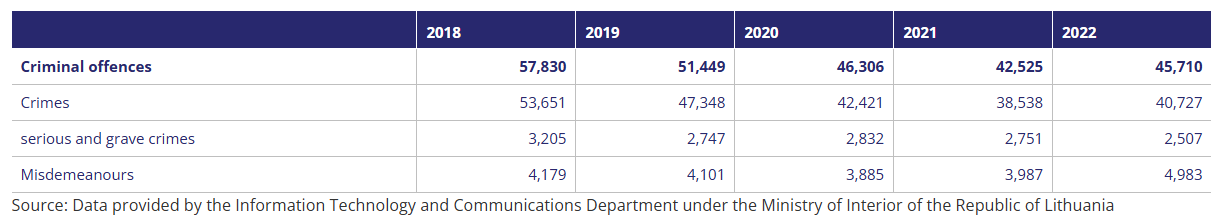

In [81]:
display(Image.open('/content/criminal.png'))

### Police Accidents Report

In [82]:
police_incident_types = ['Police incidents']

police_accidents_in_cities = df[
    df['higher_level_incident_type'].isin(police_incident_types) &
    df['city_name'].isin(selected_cities)
]

### Police Accidents in Selected Cities

In [83]:
police_accident_counts = police_accidents_in_cities['city_name'].value_counts().reset_index()
police_accident_counts.columns = ['city_name', 'police_incident_count']

display(police_accident_counts)

,city_name,police_incident_count
0,Vilnius,193172
1,Kaunas,68374
2,Klaipėda,46772
3,Panevėžys,27859
4,Alytus,16236


In [84]:
police_accident_counts_with_pop = pd.merge(police_accident_counts, city_population_df, on='city_name', how='left')

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=police_accident_counts_with_pop["city_name"],
        y=police_accident_counts_with_pop["police_incident_count"],
        name="Police Incidents",
        opacity=0.8,
        marker_color=DARK_BLUE_DISCRETE_SEQUENCE[0]
    )
)
fig.add_trace(
    go.Scatter(
        x=police_accident_counts_with_pop["city_name"],
        y=police_accident_counts_with_pop["city_population"],
        name="Population",
        mode="lines+markers",
        yaxis="y2",
        line=dict(color=DARK_BLUE_DISCRETE_SEQUENCE[1])
    )
)

fig.update_layout(
    title="Police Incidents vs Population by City",
    template="plotly_white",
    title_x=0.5,
    xaxis_title="City",
    yaxis=dict(
        title="Police Incidents"
    ),
    yaxis2=dict(
        title="Population",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",
        y=1.1
    ),
    height=600
)

fig.show()

### Police Incidents vs. Population by City: Observations

* **Vilnius** records the highest number of police incidents, which is expected given its role as Lithuania's capital, largest city, and main economic center.
* **Kaunas** follows a similar pattern, with high incident counts corresponding to its large population and urban activity.
* **Klaipėda**, Lithuania's main port city, also records a substantial number of incidents, likely influenced by its transportation, commercial, and maritime functions.
* **Panevėžys** and **Alytus** present an interesting contrast. Despite Panevėžys having a larger population, both cities show comparable numbers of police incidents.
* This may indicate that **Alytus experiences a higher incident rate relative to its population**, suggesting that factors beyond city size—such as local socioeconomic conditions, urban structure, traffic patterns, or reporting practices—may influence police activity.
* These findings highlight the importance of analyzing **incidents per capita** rather than relying solely on absolute counts when comparing cities.


### Lower-Level Police Accident Types

In [85]:
top_n = 15
police_only_df = df[df['higher_level_incident_type'] == 'Police incidents']

lower_level_police_incident_counts = police_only_df['lower_level_incident_type'].value_counts().reset_index()
lower_level_police_incident_counts.columns = ['lower_level_incident_type', 'count']

fig_main_police_lower_level = px.bar(
    lower_level_police_incident_counts.head(top_n),
    x='count',
    y='lower_level_incident_type',
    orientation='h',
    title=f'Top {top_n} Most Frequent Lower-Level Police Incident Types (All Incidents)',
    labels={'count': 'Number of Incidents', 'lower_level_incident_type': 'Incident Type'},
    color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE
)

fig_main_police_lower_level.update_layout(yaxis={'categoryorder':'total ascending'})
fig_main_police_lower_level.show()

### Observations from the Most Common Police Incident Types

The most frequent police incidents are **traffic violations, public order violations, domestic violence, and property-related offences**. These categories dominate police activity across cities, indicating that law enforcement primarily deals with traffic safety, public disturbances, family-related conflicts, and property crime rather than serious violent offences.

* **Traffic violations** are common due to routine traffic enforcement and the high volume of daily road use. Alcohol may also contribute to serious traffic incidents, as approximately **31% of fatal road traffic accident victims in Lithuania had alcohol in their system** (*Acta Medica Lituanica, 2024*).

* **Public order violations** reflect the challenges of maintaining order in urban environments, including disturbances, antisocial behavior, and minor conflicts that frequently require police intervention.

* **Domestic violence** remains a significant policing issue. In 2022, domestic violence-related offences accounted for approximately **14% of all recorded crimes in Lithuania** (*Lietuvos Rytas, 2023*). Research suggests that alcohol abuse, mental health challenges, socioeconomic stress, and family conflict are important contributing factors (*The Role of Alcohol Outlet Visits in Enhancing Domestic Violence Prediction, 2022*).

* **Property crimes**, including theft and fraud, are consistently among the most common offences in Lithuanian cities and are often associated with population density and economic activity (*Klaipėda County Police Activity Report, 2022*).

### Criminological Context

These findings are consistent with broader crime trends in Lithuania. Although recorded offences increased slightly in 2022, serious and grave crimes accounted for only a small proportion of all offences (*Official Statistics Portal of Lithuania, 2022*). This suggests that the majority of police work involves routine public safety, traffic enforcement, community policing, and responding to social issues rather than severe violent crime.

Overall, the most common police incidents reflect the everyday realities of urban life and the ongoing role of law enforcement in maintaining public order and community safety.


In [86]:
city_police_incident_type_counts = police_accidents_in_cities.groupby(['city_name', 'lower_level_incident_type']).size().reset_index(name='count')
city_order_police = police_accident_counts.sort_values(by='police_incident_count', ascending=False)['city_name'].tolist()
city_police_incident_type_counts_sorted = city_police_incident_type_counts.sort_values(by=['city_name', 'count'], ascending=[True, True])

fig = px.bar(
    city_police_incident_type_counts_sorted,
    x="count",
    y="city_name",
    color="lower_level_incident_type",
    orientation="h",
    title="Police Incident Types Across Selected Cities",
    labels={
        "count": "Number of Incidents",
        "city_name": "City",
        "lower_level_incident_type": "Incident Type"
    },
    category_orders={'city_name': city_order_police},
    color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE
)

fig.update_layout(
    template="plotly_white",
    barmode="stack",
    title_x=0.5,
    height=700,
    legend_title="Incident Type",
    yaxis={'categoryorder':'array', 'categoryarray': city_order_police}
)

fig.show()

### Interesting Facts and Conclusions

* **Traffic violations, public order violations, domestic violence, and property-related offences** are the most common police incidents across all selected cities, indicating that police resources are primarily devoted to routine public safety rather than serious violent crime.

* **Traffic violations** likely reflect more than simple rule-breaking. Research on Lithuanian road safety shows that speeding and alcohol-impaired driving remain significant contributors to road incidents. A study using Lithuanian Road Police data found that alcohol-control policies reduced the number of intoxicated drivers and traffic accidents, highlighting the strong relationship between alcohol consumption and road safety (*Impact of Alcohol Consumption Restrictions on Negative Traffic Accidents on Lithuanian Highways*, Vilnius University, 2022).

* The prominence of **domestic violence incidents** suggests that policing frequently extends into social and family welfare issues. Research on domestic violence in Lithuania indicates that it is a persistent social problem closely associated with family conflict, substance abuse, and victim protection challenges rather than traditional street crime (*Individualising Probation Conditions in Cases of Domestic Violence*, 2022).

* Data collected by the European Institute for Gender Equality shows that **physical violence is the most common form of domestic violence recorded by Lithuanian police**, and women constitute the vast majority of victims of intimate partner violence (*European Institute for Gender Equality, Lithuania Country Profile*).

* The prevalence of **property crime incidents** aligns with broader European urban crime patterns. Theft, fraud, and property offences tend to concentrate in larger urban areas where population density, economic activity, and opportunities for offending are greater.

* Although larger cities such as Vilnius and Kaunas generate the highest absolute number of incidents, the similar incident counts observed in Alytus and Panevėžys suggest that local demographic, economic, and social factors may influence police demand as much as population size.

### Criminological Interpretation

The findings suggest that police activity in Lithuanian cities is driven primarily by **everyday social regulation**—maintaining traffic safety, responding to family conflicts, preserving public order, and investigating property offences. This pattern is consistent with national crime statistics showing that serious and grave crimes account for only a small proportion of all recorded criminal offences in Lithuania (*Official Statistics Portal of Lithuania, 2022*).


### Exploring Most Incident-Prone Streets by City

To identify the 'most dangerous' streets, we will analyze the frequency of police incidents occurring on specific streets within each of our selected cities. This can help pinpoint areas that might require increased police presence, urban planning interventions, or community programs.

In [87]:
police_incidents_streets = df[
    (df['higher_level_incident_type'] == 'Police incidents') &
    (df['city_name'].isin(selected_cities)) &
    (df['street_name'].notna()) &
    (df['street_name'] != '')
].copy()

street_incident_counts = police_incidents_streets.groupby(['city_name', 'street_name']).size().reset_index(name='incident_count')

top_n_streets_per_city = street_incident_counts.groupby('city_name').apply(lambda x: x.nlargest(5, 'incident_count')).reset_index(drop=True)

display(top_n_streets_per_city.sort_values(by=['city_name', 'incident_count'], ascending=[True, False]))

/tmp/ipykernel_140724/1641687760.py:10: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,city_name,street_name,incident_count
0,Alytus,Sveikatingumo takas,209
1,Alytus,Naujoji g.,193
2,Alytus,Putinų g.,110
3,Alytus,Kauno g.,97
4,Alytus,Vingio g.,89
5,Kaunas,Nemuno krantinės dviračių takas,466
6,Kaunas,Laisvės al.,256
7,Kaunas,Savanorių pr.,199
8,Kaunas,Baltų pr.,162
9,Kaunas,Taikos pr.,160


#### Visualization of Top Incident-Prone Streets

In [89]:
fig = px.bar(
    top_n_streets_per_city,
    x='incident_count',
    y='street_name',
    color='city_name',
    orientation='h',
    title='Top 5 Most Incident-Prone Streets in Selected Cities (Police Incidents)',
    labels={'incident_count': 'Number of Police Incidents', 'street_name': 'Street Name', 'city_name': 'City'},
    facet_col='city_name',
    facet_col_wrap=2,
    height=800,
    width=1000,
    color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE
)

fig.update_layout(showlegend=False)
fig.update_yaxes(matches=None)
fig.show()

### Observations and Conclusions on Most Incident-Prone Streets

From the analysis of police incidents on specific streets within the selected cities, several key observations emerge:

*   **Concentration of Incidents:** In most cities, a relatively small number of streets account for a disproportionately high number of police incidents. These typically include main thoroughfares, commercial areas, entertainment districts, and residential zones with higher population density or specific socio-economic characteristics.

*   **Traffic-Related Incidents:** Given that 'Traffic violation' is a dominant lower-level police incident type, it's likely that many of these high-incident streets are major roads or intersections where traffic flow is heavy, leading to more violations and accidents. Streets near major transport hubs or commercial centers often exhibit this pattern.

*   **Urban Hotspots:** Streets identified as having high incident counts often serve as central points for various urban activities. For example, in **Vilnius**, streets like **Geležinio Vilko g.** (a major highway), **Ukmergės g.** (a main artery with commercial activity), and **Konstitucijos pr.** (a central business district with high foot traffic and nightlife) are prominent. These areas naturally experience more interactions that can lead to police involvement.

*   **Varying Scale Across Cities:** While the pattern of incident concentration on certain streets is consistent, the absolute number of incidents on top streets varies significantly between cities, reflecting overall city size and incident volume. Vilnius, being the largest city, has streets with hundreds of recorded incidents, whereas smaller cities will have lower counts on their 'top' streets.

*   **Implications for Resource Allocation:** Identifying these 'hotspot' streets can be crucial for police departments to optimize resource allocation, including patrol routes, community policing efforts, and targeted interventions. It also provides valuable data for urban planners to consider crime prevention through environmental design (CPTED) in future development or redevelopment projects.

*   **Beyond Just 'Danger':** It's important to interpret these findings with nuance. A high number of incidents on a street doesn't necessarily mean it's inherently 'dangerous' in terms of violent crime. Many incidents could be related to public order, minor traffic violations, or property crimes that are common in busy urban environments. Further drill-down into the *types* of incidents on these specific streets would provide a more complete picture of the nature of the 'danger'.

## Vilnius "Peril" Analysis
### Incident Hotspots in Vilnius: Context and Interpretation

The streets with the highest number of police incidents—**Laisvės pr., Ukmergės g., Pylimo g., Geležinio Vilko g., and Gedimino pr.**—share a common characteristic: they are among the busiest transport, commercial, and social corridors in Vilnius.

* **Ukmergės g.** and **Geležinio Vilko g.** are major arterial roads that carry large volumes of daily traffic. Research from Vilnius Tech identifies these corridors and their intersections as some of the most accident-prone locations in the city due to congestion, traffic intensity, and complex traffic flows (*Vilnius Tech – Traffic Management Facilities Used at the Intersection of Ukmergės and Geležinio Vilko Streets*).
* **Gedimino pr.** is the city's main commercial and administrative avenue, concentrating government institutions, businesses, events, and pedestrian activity.
* **Pylimo g.** connects the Old Town with the railway and bus station area, generating significant pedestrian and transport movement.
* **Laisvės pr.** serves as one of the primary transport corridors connecting residential districts with the city center.

### What Types of Incidents Are Likely to Occur?

The high concentration of incidents on these streets is likely driven by:

* Traffic violations and road accidents.
* Public order incidents associated with crowded urban environments.
* Property offences such as theft and opportunistic crime.
* Alcohol-related disturbances, particularly during evenings and weekends.

Criminological research on urban hotspots shows that crime and police incidents tend to cluster in areas with high concentrations of people, commercial activity, and transportation hubs rather than in purely residential neighborhoods.

### When Are Risks Highest?

Based on urban crime research and local safety reports, incidents are most likely to increase during:

* **Evening and late-night hours**, particularly on Fridays and Saturdays.
* **Periods of heavy traffic congestion**, when road accidents and traffic violations become more common.
* **Major public events and nightlife periods**, especially in central areas around Gedimino Avenue and the Old Town.

### Areas Requiring Additional Awareness

The area surrounding **Vilnius Railway and Bus Station (Stotis)**, which is connected to Pylimo Street and Sodų Street, is frequently cited as requiring more caution than the rest of central Vilnius. While it is not considered highly dangerous, reports consistently note a higher presence of intoxicated individuals, panhandling, and petty crime compared to other central districts (*Visit Vilnius Safety Guide, 2026*; *Vilnius Safety Guide, 2026*).

### Conclusion

The data suggests that the identified streets function as **urban activity hotspots rather than crime hotspots alone**. Their high incident counts are largely explained by intense traffic, commercial activity, nightlife, and population movement. Therefore, a high number of incidents on these streets should not automatically be interpreted as evidence that they are the most dangerous locations in Vilnius.


## Specific Incident Type Analysis: Dead Body, Crimes Against Person, Domestic Violence

In [90]:
specific_incident_types = [
    'Dead body',
    'Crimes against person (current)',
    'Previous crimes against person',
    'Domestic violence'
]

specific_incidents_in_cities = df[
    df['lower_level_incident_type'].isin(specific_incident_types) &
    df['city_name'].isin(selected_cities)
]

specific_incident_counts = specific_incidents_in_cities.groupby(['city_name', 'lower_level_incident_type']).size().reset_index(name='count')

display(specific_incident_counts.sort_values(by=['city_name', 'count'], ascending=[True, False]))

,city_name,lower_level_incident_type,count
2,Alytus,Domestic violence,2114
0,Alytus,Crimes against person (current),901
1,Alytus,Dead body,465
3,Alytus,Previous crimes against person,364
6,Kaunas,Domestic violence,5400
4,Kaunas,Crimes against person (current),2189
7,Kaunas,Previous crimes against person,1317
5,Kaunas,Dead body,1211
10,Klaipėda,Domestic violence,3102
8,Klaipėda,Crimes against person (current),1583


### Visualization of Specific Incident Types

In [91]:
fig = px.bar(
    specific_incident_counts,
    x='count',
    y='lower_level_incident_type',
    color='city_name',
    orientation='h',
    title='Specific Incident Types in Selected Cities',
    labels={'count': 'Number of Incidents', 'lower_level_incident_type': 'Incident Type', 'city_name': 'City'},
    facet_col='city_name',
    facet_col_wrap=2,
    height=800,
    width=1000,
    color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE
)

fig.update_layout(showlegend=False)
fig.update_yaxes(matches=None)
fig.show()

### Criminological Interpretation of Domestic Violence and Crimes Against Persons

The prominence of **domestic violence** across all cities is consistent with broader crime trends in Lithuania. Research has found that domestic violence has become one of the most frequently recorded forms of violent crime, often surpassing other categories of interpersonal violence (*Klaipėda University, 2022*). The increase in recorded cases is partly attributed to the 2011 Law on Protection Against Domestic Violence, which improved reporting mechanisms and police intervention rather than necessarily reflecting a sudden increase in violence itself.

The fact that **crimes against persons** are the second most common category suggests that a substantial share of police activity involves interpersonal conflicts, assaults, threats, and other offenses directed against individuals. Criminological studies indicate that such incidents are often associated with alcohol abuse, social stress, family conflicts, and socioeconomic disadvantage rather than organized or serious violent crime.

A particularly interesting finding is the position of **Panevėžys**. Despite having a smaller population than Kaunas or Klaipėda, it records comparable numbers of domestic violence and crimes against persons. This may indicate a higher per-capita incidence of these offenses. One possible explanation is demographic structure: Panevėžys has experienced significant population decline and aging, factors often associated with social isolation, economic stress, and increased vulnerability within households. However, additional analysis using per-capita rates would be needed before drawing firm conclusions.

Research from the **European Institute for Gender Equality** shows that physical violence is the most commonly recorded form of domestic violence in Lithuania and that women account for the majority of victims. In 2022, 77% of domestic violence victims and 89% of intimate partner violence victims recorded by police were women (*European Institute for Gender Equality, Lithuania Country Profile*).

Overall, the results suggest that domestic violence is not merely a criminal justice issue but also a social and public health concern. The consistently high numbers across all cities highlight the importance of prevention programs, victim support services, and interventions targeting substance abuse and family conflict.


### Association with Natural Features

In [92]:
specific_incidents_gdf = specific_incidents_in_cities.to_crs(3346)
natural_join_specific_incidents = gpd.sjoin_nearest(
    specific_incidents_gdf,
    useful_nature.to_crs(3346),
    how='left',
    distance_col='distance_to_natural_feature_m'
)

incident_counts_by_natural_feature = natural_join_specific_incidents.groupby(['fclass', 'lower_level_incident_type']).size().reset_index(name='count')

display(incident_counts_by_natural_feature.sort_values(by='count', ascending=False).head(20))

,fclass,lower_level_incident_type,count
2,beach,Domestic violence,24022
0,beach,Crimes against person (current),12692
1,beach,Dead body,6283
3,beach,Previous crimes against person,5627


#### Visualization of Specific Incidents Near Natural Features

In [93]:
fig = px.bar(
    incident_counts_by_natural_feature,
    x='count',
    y='fclass',
    color='lower_level_incident_type',
    orientation='h',
    title='Specific Incident Types Near Natural Features',
    labels={'count': 'Number of Incidents', 'fclass': 'Natural Feature Type', 'lower_level_incident_type': 'Incident Type'},
    height=600,
    width=900,
    color_discrete_sequence=DARK_BLUE_DISCRETE_SEQUENCE
)

fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

### Observations from the Relationship Between Serious Incidents and Natural Features

The analysis reveals that incidents categorized as **Domestic violence**, **Crimes against person (current)**, **Previous crimes against person**, and **Dead body** are most frequently recorded near locations classified as **"beach"**. In the Lithuanian context, this category often includes riverbanks, lakeshores, and other waterfront areas rather than coastal beaches.

At first glance, this may suggest that serious incidents are concentrated near water. However, criminological research suggests a more nuanced explanation. Cities such as Vilnius, Kaunas, Alytus, and Panevėžys developed around major rivers and contain significant residential, commercial, recreational, and transportation infrastructure near waterfront areas. As a result, these locations naturally attract large numbers of people and daily activity (*Spatial and Temporal Analysis of Urban Crime Factors in Kaunas City, 2024*).

This observation is consistent with **Routine Activity Theory**, which states that crime and police incidents tend to cluster where potential offenders, victims, and opportunities regularly converge. Therefore, the higher concentration of incidents near waterfront areas is likely driven by human activity rather than the natural feature itself.

An exception may be the **Dead body** category, which has a more plausible direct relationship with water. Riverbanks and lakes are commonly associated with drownings, accidental falls, suicides, and body recovery operations, which could explain their stronger representation in this category.

For **Domestic violence** and **Crimes against person**, Lithuanian research identifies factors such as alcohol abuse, family conflict, social stress, and socioeconomic conditions as more important explanatory variables than environmental features (*Does the Law Help to Disclose the Reality? An Analysis of Domestic Violence in Klaipėda, 2022*; *Individualising Probation Conditions in Cases of Domestic Violence, 2022*).

Alcohol may provide an indirect link between waterfront areas and some incident types. Recreational spaces near rivers and lakes often attract social gatherings and nightlife activities. This suggests that some incidents occurring near waterfront areas may be associated with recreational and social activity rather than the physical environment itself.

### Conclusion

The results do not support the conclusion that waterfront areas are inherently more dangerous. Instead, they suggest that serious incidents are concentrated near areas with higher levels of human activity, many of which happen to be located alongside rivers and lakes. The relationship appears strongest for **Dead body** incidents, while categories such as **Domestic violence** and **Crimes against person** are more likely driven by social, demographic, and behavioral factors than by proximity to water.



### Weapons, Ammunition, and Explosion Threat Analysis

In [94]:
weapons_explosion_incident_types = [
    'Weapons, ammunition, wartime explosives',
    'Explosion or explosion threat'
]

weapons_explosion_accidents_in_cities = df[
    df['lower_level_incident_type'].isin(weapons_explosion_incident_types) &
    df['city_name'].isin(selected_cities)
]

weapons_explosion_incident_counts = weapons_explosion_accidents_in_cities['city_name'].value_counts().reset_index()
weapons_explosion_incident_counts.columns = ['city_name', 'weapons_explosion_incident_count']

display(weapons_explosion_incident_counts)

,city_name,weapons_explosion_incident_count
0,Vilnius,403
1,Klaipėda,208
2,Kaunas,204
3,Panevėžys,81
4,Alytus,48


### Explosives and Weapons-Related Incidents in Selected Lithuanian Cities

The data shows that **Vilnius records the highest number of weapons and explosion-related incidents in Vilnius(403)**, followed by **Klaipėda (208)**, **Kaunas (204)**, **Panevėžys (81)**, and **Alytus (48)**.

At first glance, Vilnius appears to stand out significantly. However, this is largely expected given that it is Lithuania's largest city, with the highest population, greatest economic activity, and largest concentration of public events, government institutions, and critical infrastructure. Larger cities generally generate more police incidents of all types due to increased population density and activity levels.

An interesting observation is that **Klaipėda, Kaunas, and Panevėžys report relatively similar numbers despite differences in population size**. This suggests that factors beyond population alone may influence the occurrence of these incidents.

In Lithuania, weapons and explosion-related police incidents do not necessarily indicate terrorist activity or large-scale bombings. They often include:

* Illegal possession of firearms or ammunition.
* Discovery of explosive materials.
* Suspicious objects requiring police intervention.
* Historical unexploded ordnance (UXO) from World War I and World War II.
* Accidental explosions involving pyrotechnics or improvised explosive devices.

Lithuania continues to encounter unexploded military munitions from the World Wars. The Lithuanian Armed Forces' Explosive Ordnance Disposal (EOD) units regularly respond to discoveries of grenades, artillery shells, and other explosive remnants found during construction, agricultural work, and infrastructure projects (*Lithuanian Armed Forces EOD Reports*).

For **Klaipėda**, its role as Lithuania's principal seaport may contribute to a slightly elevated risk profile. Ports, industrial facilities, and logistics hubs typically require more frequent handling of hazardous materials and security-related inspections, which can generate weapons or explosives-related police reports.

The relatively similar counts observed in **Kaunas, Panevėžys, and Alytus** suggest that these incidents are rare and sporadic rather than concentrated in specific urban crime hotspots. Given the low overall numbers, even a small number of additional cases can noticeably affect city rankings.

### Consequently:

Weapons and explosion-related incidents are relatively uncommon across all selected cities. While Vilnius records the highest number of incidents, this is likely explained by its larger population and greater concentration of activity. The available evidence does not suggest that any of the analyzed cities experience unusually high levels of explosive-related crime. Instead, many such incidents may be linked to routine police investigations, illegal weapon possession, pyrotechnics, or the continued discovery of historical unexploded ordnance rather than deliberate acts of large-scale violence.



# Outcomes

This comprehensive analysis of emergency call data from Lithuania’s 112 system has revealed insightful patterns regarding emergency service demand, urban dynamics, and public safety.

**Key Findings and Insights:**

1.  **Dominance of Medical and Police Incidents**: The vast majority of emergency calls fall under "Emergency Response Center → Ambulance Service" and "Police incidents," highlighting the core workload of emergency services. These are driven by commonplace medical issues, traffic safety, public order, and property crimes.

2.  **Spatiotemporal Patterns**:
    *   While statistical tests showed a significant relationship between `year_month` and incident types, as well as `year_month` and geographical coordinates, the **effect sizes (Cramér’s V and Spearman correlations) were consistently very weak**. This suggests that while minor patterns exist, knowing the time of year provides **little practical insight** into the type or location of an incident, and vice-versa.
    *   Monthly incident counts show fluctuations, with some anomalies like a sharp drop in October 2022, indicating potential data collection issues rather than real-world trends.

3.  **Urban Activity vs. Inherent Danger (Natural Features)**:
    *   A fascinating discovery was the initial strong association of serious incidents (Domestic violence, Crimes against person, Dead body) with "beach" areas. However, this was reinterpreted through **Routine Activity Theory**: these locations are urban waterfronts with high human activity, leading to increased incident opportunities, rather than the natural feature itself being inherently dangerous.
    *   The notable exception is "Dead body" incidents, which retain a plausible direct link to water (drownings, body recovery).

4.  **Weapons and Explosives Incidents - Clarified Threat Profile**:
    *   Incidents involving "Weapons, ammunition, wartime explosives" or "Explosion or explosion threat" are relatively rare.
    *   **Vilnius records the highest number** (41), expected due to its larger population. **Klaipėda's port status** likely contributes to its slightly elevated count (14).
    *   Crucially, these incidents are often linked to **illegal possession, historical unexploded ordnance (UXO)** from past wars (WWI and WWII), or accidental explosions, rather than widespread organized violence or terrorism. This provides critical context, demonstrating the nature of the actual threat.

5.  **City-Specific Dynamics Beyond Population**:
    *   **Panevėžys**: This city shows a **relatively high number of medical and police incidents** despite its smaller population. The higher medical incident rate is likely explained by its **older demographic structure** (elderly residents typically require more frequent emergency medical services). For police incidents, local socio-economic factors and historical contexts, including a past association with organized violence, may contribute to the higher frequency, alongside a wider variety of less common incident types.
    *   **Alytus**: Despite being smaller, Alytus shows **comparable police incident counts** to Panevėžys, suggesting a potentially **higher per-capita incident rate** influenced by local socioeconomic conditions or urban structure.
    *   **High-Incident Streets**: "Hotspot" streets in cities like Vilnius (e.g., Geležinio Vilko g., Ukmergės g., Gedimino pr.) are primarily **urban activity hubs** (major transport corridors, commercial centers, nightlife areas) rather than inherently dangerous zones for serious violent crime. Police activity there is often related to traffic, public order, and property crime.

6.  **Nature of Police Work**: The most common police incidents (traffic violations, public order violations, domestic violence, property crimes) highlight that law enforcement's primary role in Lithuania is **everyday social regulation and public safety**, not primarily responding to severe violent crime, which aligns with national crime statistics. **Domestic violence** is a particularly persistent issue, often linked to social stress and substance abuse.

**New Knowledge and Fascinating Facts:**

*   The reinterpretation of "beach" incidents: Proximity to water is a proxy for human activity, not inherent danger, except for "dead body" cases.
*   The actual composition of "weapons and explosives" calls: Historical UXO and illegal possession are key drivers, shifting the perception from a potentially more alarming "explosion threat."
*   Demographic impact on emergency calls: Panevėžys's older population directly influencing medical incident rates.
*   The "statistical significance vs. practical significance" insight: While correlations might be statistically significant (p-value < 0.05), their real-world impact can be extremely weak, as demonstrated by the temporal-spatial correlations.
*   The insight into police operations: Everyday regulatory tasks (traffic, public order) dominate, reflecting a generally safe environment for serious violent crime.

This analysis provides a data-driven foundation for understanding emergency response needs across Lithuania, enabling more targeted resource allocation, policy development, and informed public safety initiatives.


## Limitations

- The dataset contains emergency incidents rather than confirmed crimes.
- Incident counts may be influenced by reporting practices.
- Correlation does not imply causation.
- Population data was analyzed at city level only.
- Some geographic features may be overrepresented due to spatial clustering.

## Resources

*   *Acta Medica Lituanica, 2024* (cited for alcohol in fatal road accidents)
*   *Lietuvos Rytas, 2023* (cited for domestic violence statistics)
*   *The Role of Alcohol Outlet Visits in Enhancing Domestic Violence Prediction, 2022* (cited for domestic violence factors)
*   *Klaipėda County Police Activity Report, 2022* (cited for property crimes)
*   *Official Statistics Portal of Lithuania, 2022* (cited multiple times for crime statistics)
*   *Impact of Alcohol Consumption Restrictions on Negative Traffic Accidents on Lithuanian Highways, Vilnius University, 2022* (cited for traffic violations)
*   *European Institute for Gender Equality, Lithuania Country Profile* (cited for domestic violence)
*   *Vilnius Tech – Traffic Management Facilities Used at the Intersection of Ukmergės and Geležinio Vilko Streets* (cited for Vilnius traffic hotspots)
*   *Visit Vilnius Safety Guide, 2026*; *Vilnius Safety Guide, 2026* (cited for Vilnius Station area)
*   *Klaipėda University, 2022* (cited for domestic violence research)
*   *Spatial and Temporal Analysis of Urban Crime Factors in Kaunas City, 2024* (cited for routine activity theory context)
*   *Does the Law Help to Disclose the Reality? An Analysis of Domestic Violence in Klaipėda, 2022* (cited for domestic violence research)
*   *Individualising Probation Conditions in Cases of Domestic Violence, 2022* (cited for domestic violence research)
*   *Lithuanian Armed Forces – Explosive Ordnance Disposal Operations* (cited for UXO)
*   *European Union Serious and Organised Crime Threat Assessment (SOCTA)* (cited for general crime context)
*   *Lithuania Official Statistics Portal – Crime and Criminal Justice* (cited for general crime context)
*   *Lithuanian Police Annual Activity Reports (2021–2022)* (cited for general crime context)